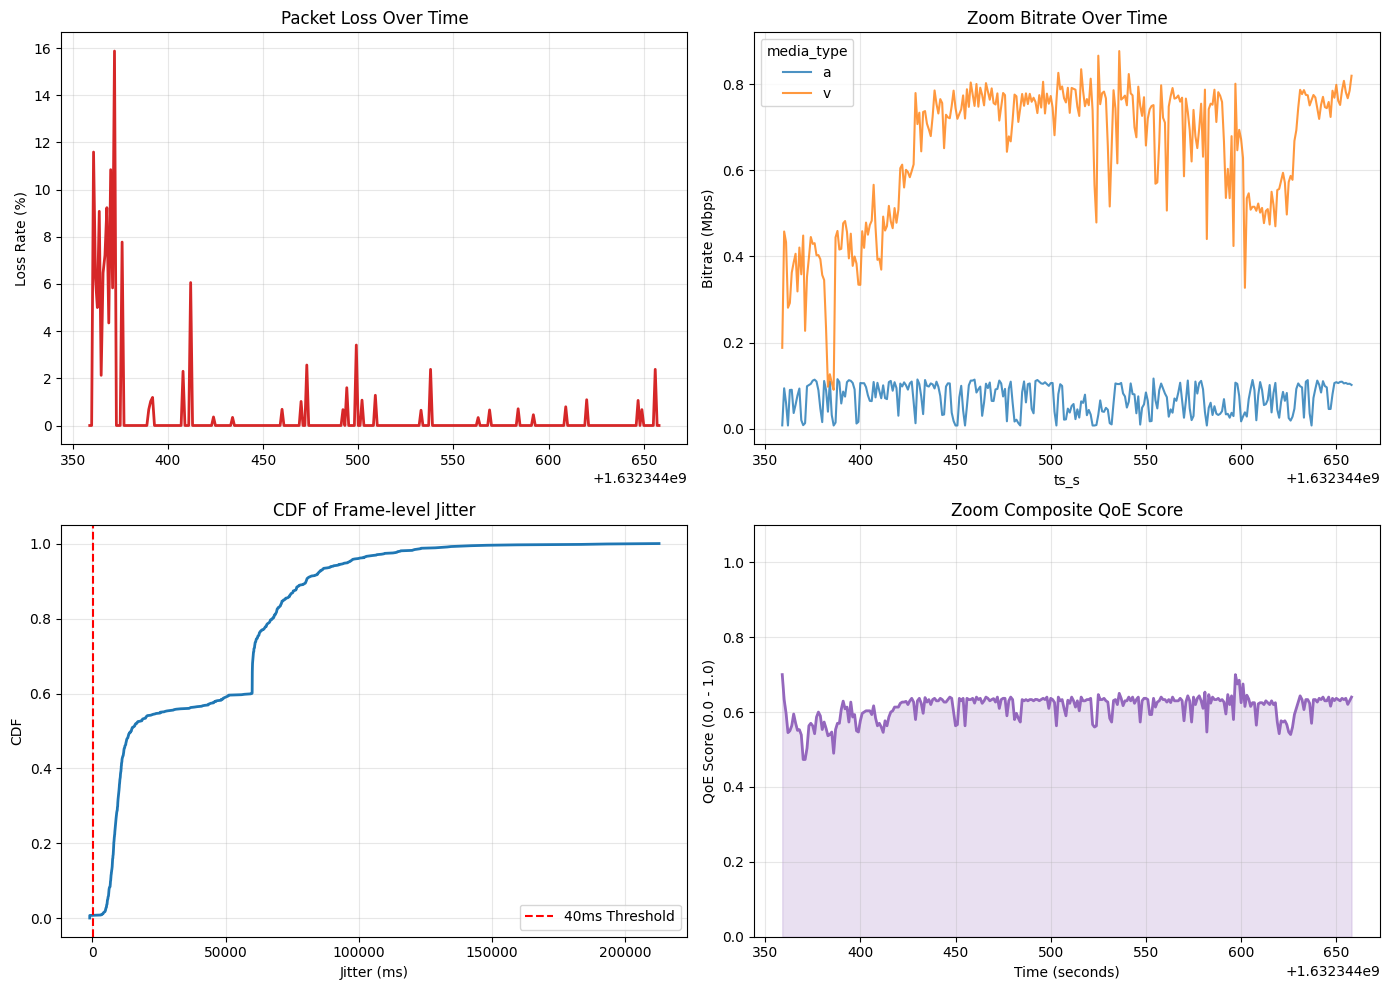

ZOOM QoE PERFORMANCE SUMMARY
Average QoE Score:    0.613 / 1.000
Minimum QoE Score:    0.238
--------------------------------------------------
Avg Loss Rate:        0.47%
Avg Frame Rate:       25.57 FPS
Avg Jitter:           37335.52 ms


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. METRIC CALCULATION
# Loss Rate (0 to 1)
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Bitrate (Mbps)
if 'bytes' in df.columns:
    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6

# Jitter (ms)
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000

# 3. QoE SCORE CALCULATION (Based on Image Formula)
# Weights: Adjust these based on your specific requirements (must sum to 1.0)
w1, w2, w3 = 0.4, 0.3, 0.3

# Normalizing FPS: Zoom targets 30 FPS
# We use .clip(0, 1) to ensure the ratio doesn't exceed 1.0 if FPS > 30
df['fps_norm'] = (df['frames'] / 30).clip(0, 1)

# Normalizing Jitter: Threshold is 40ms per the formula
# If jitter is > 40ms, this value becomes 0 (worst quality)
df['jitter_norm'] = (1 - (df['jitter_ms'] / 40)).clip(0, 1)

# Composite QoE Calculation
df['qoe_score'] = (w1 * (1 - df['loss_rate'])) + \
                  (w2 * df['fps_norm']) + \
                  (w3 * df['jitter_norm'])

# Group by second for time-series analysis
qoe_over_time = df.groupby("ts_s")["qoe_score"].mean().reset_index()
loss_over_time = df.groupby("ts_s")["loss_rate"].mean().reset_index()

# 4. PLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss Rate
axes[0,0].plot(loss_over_time['ts_s'], loss_over_time['loss_rate'] * 100, color='#d62728', linewidth=2)
axes[0,0].set_ylabel('Loss Rate (%)')
axes[0,0].set_title('Packet Loss Over Time')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Bitrate
if 'bitrate_mbps' in df.columns:
    if 'media_type' in df.columns:
        bitrate_by_type = df.groupby(['ts_s', 'media_type'])['bitrate_mbps'].sum().unstack().fillna(0)
        bitrate_by_type.plot(ax=axes[0,1], alpha=0.8)
    else:
        axes[0,1].plot(df.groupby('ts_s')['bitrate_mbps'].sum(), color='#2ca02c')
    axes[0,1].set_ylabel('Bitrate (Mbps)')
    axes[0,1].set_title('Zoom Bitrate Over Time')
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Jitter CDF
if 'jitter_ms' in df.columns:
    sorted_jitter = np.sort(df['jitter_ms'].dropna())
    cdf = np.arange(1, len(sorted_jitter) + 1) / len(sorted_jitter)
    axes[1,0].plot(sorted_jitter, cdf, color='#1f77b4', linewidth=2)
    axes[1,0].axvline(40, color='red', linestyle='--', label='40ms Threshold')
    axes[1,0].set_xlabel('Jitter (ms)')
    axes[1,0].set_ylabel('CDF')
    axes[1,0].set_title('CDF of Frame-level Jitter')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

# Plot 4: COMPOSITE QoE SCORE (New)
axes[1,1].plot(qoe_over_time['ts_s'], qoe_over_time['qoe_score'], color='#9467bd', linewidth=2)
axes[1,1].fill_between(qoe_over_time['ts_s'], qoe_over_time['qoe_score'], alpha=0.2, color='#9467bd')
axes[1,1].set_ylabel('QoE Score (0.0 - 1.0)')
axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].set_title('Zoom Composite QoE Score')
axes[1,1].set_ylim(0, 1.1)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zoom_qoe_analysis.png', dpi=150)
plt.show()

# 5. ENHANCED SUMMARY STATISTICS
print("=" * 50)
print("ZOOM QoE PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Average QoE Score:    {df['qoe_score'].mean():.3f} / 1.000")
print(f"Minimum QoE Score:    {df['qoe_score'].min():.3f}")
print("-" * 50)
print(f"Avg Loss Rate:        {df['loss_rate'].mean()*100:.2f}%")
print(f"Avg Frame Rate:       {df['frames'].mean():.2f} FPS")
print(f"Avg Jitter:           {df['jitter_ms'].mean():.2f} ms")
print("=" * 50)

# Save full results
df.to_csv("detailed_qoe_results.csv", index=False)

File loaded successfully!
Columns: ['ts_s', 'report_count', 'rtp_ssrc', 'media_type', 'stream_type', 'ip_src', 'tp_src', 'ip_dst', 'tp_dst', 'pkts', 'bytes', 'lost', 'duplicate', 'out_of_order', 'frames', 'mean_frame_len', 'mean_jitter']

First few rows:
         ts_s  report_count  rtp_ssrc media_type stream_type       ip_src  \
0  1632344359             0  16778241          v           f  10.9.121.28   
1  1632344359             0  16778241          v           m  10.9.121.28   
2  1632344359             0  16778242          a           m  10.9.121.28   
3  1632344360             1  16778241          v           m  10.9.121.28   
4  1632344360             1  16778241          v           f  10.9.121.28   

   tp_src        ip_dst  tp_dst  pkts  bytes  lost  duplicate  out_of_order  \
0   65027  144.195.52.3    8801     3   3614     0          0             1   
1   65027  144.195.52.3    8801    20  19874     0          0             4   
2   55189  144.195.52.3    8801     9   1002 

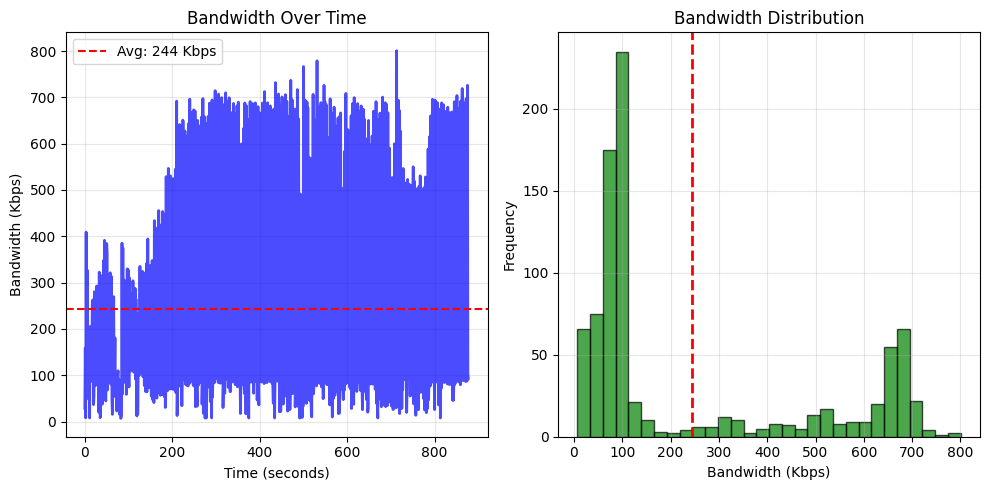


=== FOR YOUR PAPER ===
'Video stream bandwidth averages 0.2 Mbps (244 Kbps), ranging from 0.0 to 0.8 Mbps.'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the stats.csv file
df = pd.read_csv('stats.csv')

print("File loaded successfully!")
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# 2. Check which column contains bandwidth data
# Try different possible column names
bitrate_col = None
for col in ['bytes_per_sec', 'bitrate_bps', 'bytes', 'bitrate', 'bytes_sec']:
    if col in df.columns:
        bitrate_col = col
        print(f"\nUsing column: '{bitrate_col}'")
        break

if bitrate_col:
    # 3. Convert to Kbps based on column name
    if 'bytes' in bitrate_col:  # bytes_per_sec or bytes_sec
        kbps = df[bitrate_col] * 8 / 1000  # bytes/sec → Kbps
        unit = "bytes/sec → Kbps"
    elif 'bps' in bitrate_col:  # bitrate_bps
        kbps = df[bitrate_col] / 1000  # bps → Kbps
        unit = "bps → Kbps"
    else:  # Unknown, assume Kbps
        kbps = df[bitrate_col]
        unit = "assuming Kbps"
    
    print(f"Conversion: {unit}")
    
    # 4. Calculate statistics for your paper
    print(f"\n=== BANDWIDTH STATISTICS ===")
    print(f"Average: {kbps.mean():.0f} Kbps ({kbps.mean()/1000:.2f} Mbps)")
    print(f"Minimum: {kbps.min():.0f} Kbps")
    print(f"Maximum: {kbps.max():.0f} Kbps")
    print(f"Std Dev: {kbps.std():.0f} Kbps")
    print(f"Median:  {kbps.median():.0f} Kbps")
    print(f"95th %:  {kbps.quantile(0.95):.0f} Kbps")
    
    # 5. Create simple plot
    plt.figure(figsize=(10, 5))
    
    # Time series plot
    plt.subplot(1, 2, 1)
    plt.plot(kbps.values, color='blue', alpha=0.7, linewidth=2)
    plt.axhline(y=kbps.mean(), color='red', linestyle='--', label=f'Avg: {kbps.mean():.0f} Kbps')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Bandwidth (Kbps)')
    plt.title('Bandwidth Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Histogram
    plt.subplot(1, 2, 2)
    plt.hist(kbps.values, bins=30, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(x=kbps.mean(), color='red', linestyle='--', linewidth=2)
    plt.xlabel('Bandwidth (Kbps)')
    plt.ylabel('Frequency')
    plt.title('Bandwidth Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('bandwidth_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 6. For your paper:
    print(f"\n=== FOR YOUR PAPER ===")
    print(f"'Video stream bandwidth averages {kbps.mean()/1000:.1f} Mbps "
          f"({kbps.mean():.0f} Kbps), ranging from {kbps.min()/1000:.1f} to "
          f"{kbps.max()/1000:.1f} Mbps.'")
    
else:
    print("\nERROR: No bandwidth column found!")
    print("Your stats.csv has these columns:", df.columns.tolist())
    print("\nTry looking for one of these columns in your data.")